In [5]:
#Step 1: Import Necessary LibrariesImport all required libraries for data processing, model training, evaluation, and visualization.

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
#Step 2: Load and Prepare DataLoad the dataset, display its shape and columns, and prepare features (X) and target (y) for binary classification.

data = pd.read_csv("processed_feature_selected.csv")
print("Data shape:", data.shape)
print("Columns:", data.columns.tolist())
print("\nData Preview:")
print(data.head())

# Define features and target
X = data.drop(['title', 'health_score', 'fat_level'], axis=1)
y = (data['health_score'] > 0.5).astype(int)  # 1=healthy, 0=not healthy

# Split data: 70% train, 15% validation, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE)

Data shape: (10619, 11)
Columns: ['title', 'rating', 'fat', 'calories', 'protein', 'sodium', 'high fiber', 'fat_level_medium', 'fat_level_high', 'fat_level', 'health_score']

Data Preview:
                                               title    rating       fat  \
0        Boudin Blanc Terrine with Red Onion Confit   0.666667  0.310811   
1                      Potato and Fennel Soup Hodge   0.333333  0.094595   
2                          Spinach Noodle Casserole   0.000000  0.432432   
3                             Korean Marinated Beef   0.666667  0.135135   
4  Ham Persillade with Mustard Potato Salad and M...  0.333333  0.554054   

   calories   protein    sodium  high fiber  fat_level_medium  fat_level_high  \
0  0.335554  0.264706  0.840047         0.0               0.0             1.0   
1  0.137386  0.088235  0.096322         0.0               0.0             0.0   
2  0.455454  0.294118  0.263865         0.0               0.0             1.0   
3  0.141549  0.102941  0.74255

In [7]:
#Step 3: Train and Evaluate Basic Decision TreeTrain a basic Decision Tree model and evaluate its performance (Accuracy, Precision, Recall, F1 Score) on Train, Validation, and Test sets.

dt_basic = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_basic.fit(X_train, y_train)

# Evaluate on Training Set
y_train_pred_basic = dt_basic.predict(X_train)
train_metrics_basic = {
    'Accuracy': accuracy_score(y_train, y_train_pred_basic),
    'Precision': precision_score(y_train, y_train_pred_basic),
    'Recall': recall_score(y_train, y_train_pred_basic),
    'F1 Score': f1_score(y_train, y_train_pred_basic)
}

# Evaluate on Validation Set
y_val_pred_basic = dt_basic.predict(X_val)
val_metrics_basic = {
    'Accuracy': accuracy_score(y_val, y_val_pred_basic),
    'Precision': precision_score(y_val, y_val_pred_basic),
    'Recall': recall_score(y_val, y_val_pred_basic),
    'F1 Score': f1_score(y_val, y_val_pred_basic)
}

# Evaluate on Test Set
y_test_pred_basic = dt_basic.predict(X_test)
test_metrics_basic = {
    'Accuracy': accuracy_score(y_test, y_test_pred_basic),
    'Precision': precision_score(y_test, y_test_pred_basic),
    'Recall': recall_score(y_test, y_test_pred_basic),
    'F1 Score': f1_score(y_test, y_test_pred_basic)
}

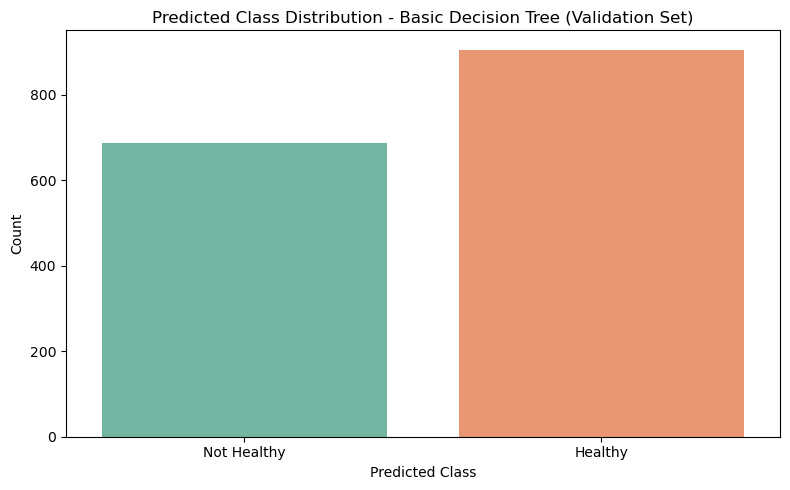

In [27]:
#Step 4: Visualize Predicted Class Distribution for Basic Model (Validation Set)Create a count plot to show the distribution of predicted classes (Healthy vs. Not Healthy) for the basic model on the validation set.

plt.figure(figsize=(8, 5))
sns.countplot(x=y_val_pred_basic, hue=y_val_pred_basic, palette='Set2', legend=False)
plt.xticks([0, 1], ['Not Healthy', 'Healthy'])
plt.title('Predicted Class Distribution - Basic Decision Tree (Validation Set)')
plt.xlabel('Predicted Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [10]:
## Step 5: Hyperparameter Tuning for Decision TreePerform hyperparameter tuning using GridSearchCV to find the best parameters for the Decision Tree model.
param_grid = {
    'max_depth': [3, 5, 7],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 5]
}
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
grid_search = GridSearchCV(dt, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best tuned model
best_dt_model = grid_search.best_estimator_
print("\nBest Hyperparameters:", grid_search.best_params_)


Best Hyperparameters: {'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 5}


In [12]:
# Step 6: Evaluate Tuned Decision TreeEvaluate the tuned Decision Tree model on Train, Validation, and Test sets.

# Evaluate tuned model on Training Set
y_train_pred_tuned = best_dt_model.predict(X_train)
train_metrics_tuned = {
    'Accuracy': accuracy_score(y_train, y_train_pred_tuned),
    'Precision': precision_score(y_train, y_train_pred_tuned),
    'Recall': recall_score(y_train, y_train_pred_tuned),
    'F1 Score': f1_score(y_train, y_train_pred_tuned)
}

# Evaluate tuned model on Validation Set
y_val_pred_tuned = best_dt_model.predict(X_val)
val_metrics_tuned = {
    'Accuracy': accuracy_score(y_val, y_val_pred_tuned),
    'Precision': precision_score(y_val, y_val_pred_tuned),
    'Recall': recall_score(y_val, y_val_pred_tuned),
    'F1 Score': f1_score(y_val, y_val_pred_tuned)
}

# Evaluate tuned model on Test Set
y_test_pred_tuned = best_dt_model.predict(X_test)
test_metrics_tuned = {
    'Accuracy': accuracy_score(y_test, y_test_pred_tuned),
    'Precision': precision_score(y_test, y_test_pred_tuned),
    'Recall': recall_score(y_test, y_test_pred_tuned),
    'F1 Score': f1_score(y_test, y_test_pred_tuned)
}

In [13]:
# Step 7: Model Comparison and Overfitting CheckCompare the basic and tuned models using a DataFrame and check for overfitting by analyzing validation-test gaps.

comparison_data = {
    'Model': ['Basic', 'Basic', 'Basic', 'Tuned', 'Tuned', 'Tuned'],
    'Dataset': ['Train', 'Validation', 'Test', 'Train', 'Validation', 'Test'],
    'F1 Score': [train_metrics_basic['F1 Score'], val_metrics_basic['F1 Score'], test_metrics_basic['F1 Score'],
                 train_metrics_tuned['F1 Score'], val_metrics_tuned['F1 Score'], test_metrics_tuned['F1 Score']],
    'Accuracy': [train_metrics_basic['Accuracy'], val_metrics_basic['Accuracy'], test_metrics_basic['Accuracy'],
                train_metrics_tuned['Accuracy'], val_metrics_tuned['Accuracy'], test_metrics_tuned['Accuracy']]
}
comparison_df = pd.DataFrame(comparison_data)
print("\nModel Comparison (Basic vs Tuned Decision Tree):")
print(comparison_df.round(4))

# Check for overfitting (Validation-Test Gap for Tuned Model)
print("\nOverfitting Check for Tuned Model (Val-Test Gaps):")
for metric in val_metrics_tuned:
    gap = val_metrics_tuned[metric] - test_metrics_tuned[metric]
    print(f"  {metric}: {gap:.4f}")
if max(val_metrics_tuned[metric] - test_metrics_tuned[metric] for metric in val_metrics_tuned) > 0.1:
    print("Warning: Potential overfitting (gap > 0.1).")
else:
    print("Good: Low val-test gaps indicate generalization.")


Model Comparison (Basic vs Tuned Decision Tree):
   Model     Dataset  F1 Score  Accuracy
0  Basic       Train    1.0000    1.0000
1  Basic  Validation    0.9785    0.9755
2  Basic        Test    0.9793    0.9768
3  Tuned       Train    0.9877    0.9864
4  Tuned  Validation    0.9779    0.9749
5  Tuned        Test    0.9753    0.9724

Overfitting Check for Tuned Model (Val-Test Gaps):
  Accuracy: 0.0025
  Precision: 0.0047
  Recall: 0.0004
  F1 Score: 0.0025
Good: Low val-test gaps indicate generalization.


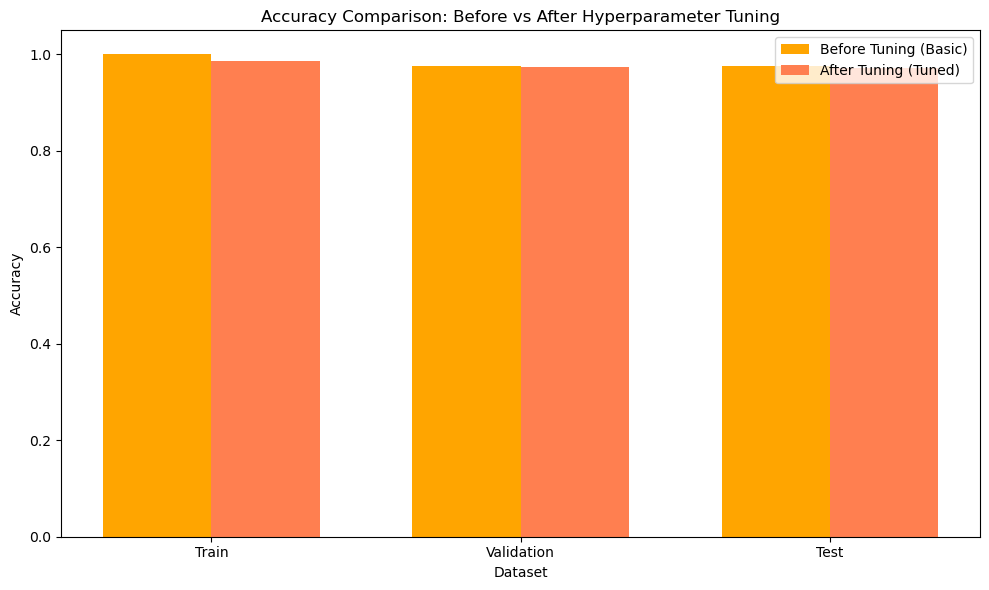

In [14]:
# Step 8: Visualize Accuracy Before and After Hyperparameter TuningCreate a bar plot comparing the Accuracy of the basic (before tuning) and tuned Decision Tree models across Train, Validation, and Test sets.

plt.figure(figsize=(10, 6))
x = np.arange(len(comparison_df['Dataset'].unique()))  # Train, Validation, Test
width = 0.35

# Accuracy Bar Plot
plt.bar(x - width/2, comparison_df[comparison_df['Model'] == 'Basic']['Accuracy'], width, label='Before Tuning (Basic)', color='orange')
plt.bar(x + width/2, comparison_df[comparison_df['Model'] == 'Tuned']['Accuracy'], width, label='After Tuning (Tuned)', color='coral')

plt.xlabel('Dataset')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison: Before vs After Hyperparameter Tuning')
plt.xticks(x, ['Train', 'Validation', 'Test'])
plt.legend()
plt.tight_layout()
plt.show()

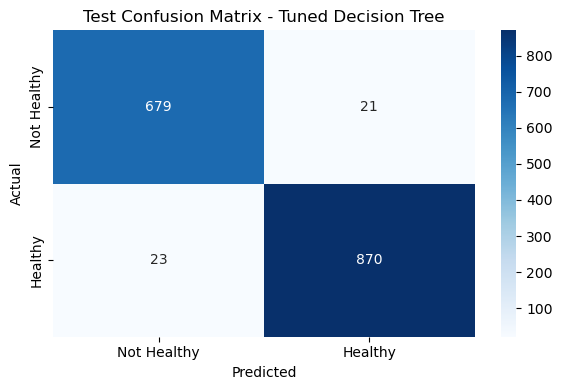

In [16]:
# Step 9: Visualize Confusion Matrix for Tuned Model (Test Set)Display a heatmap of the confusion matrix for the tuned model on the test set.

cm_test = confusion_matrix(y_test, y_test_pred_tuned)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Healthy', 'Healthy'], 
            yticklabels=['Not Healthy', 'Healthy'])
plt.title('Test Confusion Matrix - Tuned Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

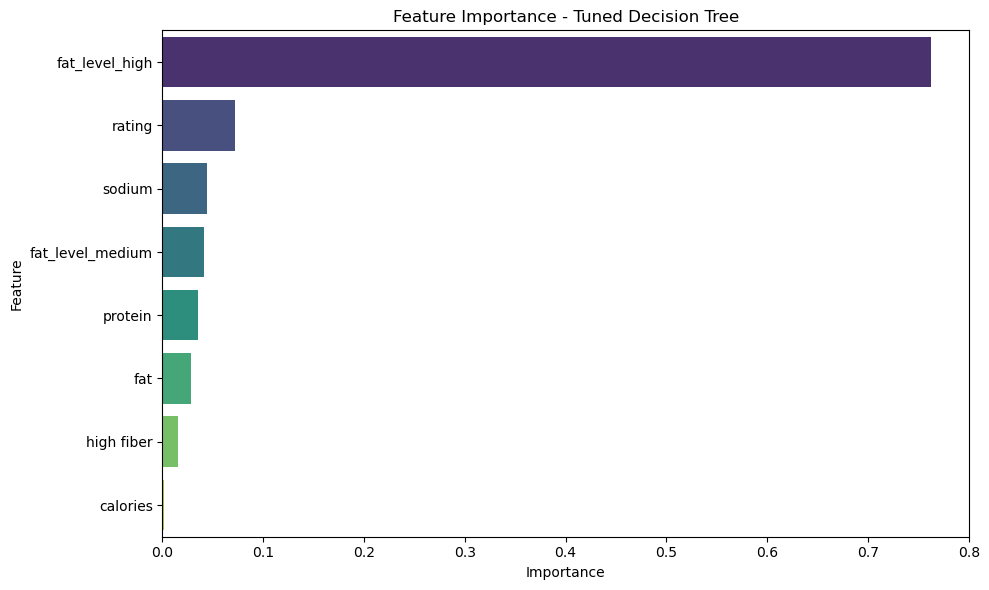

In [29]:
# Step 10: Visualize Feature Importance for Tuned ModelCreate a bar plot showing the importance of each feature in the tuned Decision Tree model.

feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=feature_importances, palette='viridis', legend=False)
plt.title('Feature Importance - Tuned Decision Tree')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

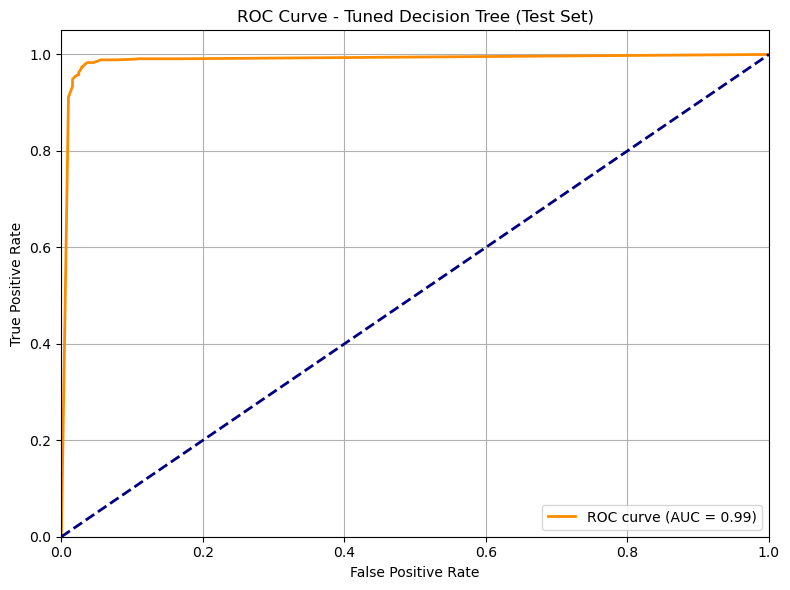

In [21]:
# Step 12: Visualize ROC Curve for Tuned Model (Test Set)Plot the Receiver Operating Characteristic (ROC) curve for the tuned model on the test set.
y_test_proba = best_dt_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tuned Decision Tree (Test Set)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
# Step 13: Save Tuned ModelSave the tuned Decision Tree model to a pickle file.

models_dir = "../models"
os.makedirs(models_dir, exist_ok=True)
model_filename = os.path.join(models_dir, "tuned_decision_tree_model.pkl")
with open(model_filename, "wb") as f:
    pickle.dump(best_dt_model, f)
print(f"\nTuned model saved to {model_filename}")

print("\nModel training, tuning, evaluation, and visualizations complete!")


Tuned model saved to ../models\tuned_decision_tree_model.pkl

Model training, tuning, evaluation, and visualizations complete!
